In [1]:
# Import Libraries
from pathlib import Path

import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: d:\Crop_Disease_Detection


In [2]:
# Dataset Path
dataset_path = Path("../data/raw/color")

print(dataset_path.resolve())

D:\Crop_Disease_Detection\data\raw\color


In [3]:
# Define Constants
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

In [4]:
# Create Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


In [5]:
# Create Validation Dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [6]:
# Check Class Name
class_names = train_dataset.class_names

print("Total Classes:", len(class_names))

class_names

Total Classes: 38


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [7]:
# Check Dataset Size
print("Training Batches:", len(train_dataset))
print("Validation Batches:", len(validation_dataset))

Training Batches: 1358
Validation Batches: 340


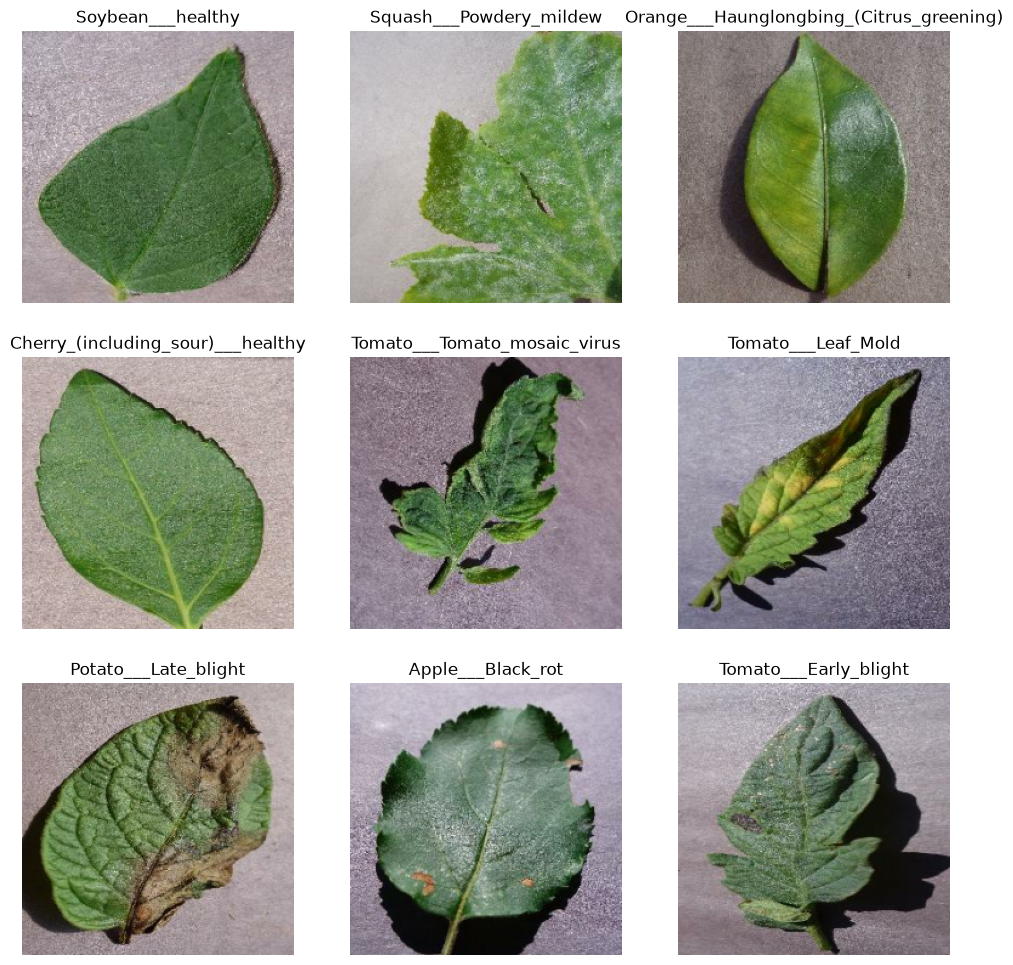

In [8]:
# Display Sample Images
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [20]:
from src.preprocessing.data_loader import load_dataset

In [23]:
import importlib
import src.preprocessing.data_loader as dl

importlib.reload(dl)

train_ds, val_ds, class_names = dl.load_dataset(
    dataset_path="../data/raw/color"
)

print(f"Total Classes: {len(class_names)}")
print(class_names[:5])

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [24]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [25]:
import importlib
import src.preprocessing.data_loader as dl

importlib.reload(dl)

<module 'src.preprocessing.data_loader' from 'D:\\Crop_Disease_Detection\\src\\preprocessing\\data_loader.py'>

In [26]:
from config import DATASET_PATH

train_ds, val_ds, class_names = dl.load_dataset(DATASET_PATH)

print(f"Total Classes : {len(class_names)}")
print(class_names[:5])

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Total Classes : 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [27]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [28]:
import importlib
import src.preprocessing.data_loader as dl

importlib.reload(dl)

<module 'src.preprocessing.data_loader' from 'D:\\Crop_Disease_Detection\\src\\preprocessing\\data_loader.py'>

In [29]:
train_ds, val_ds, class_names = dl.load_dataset()

print("Total Classes:", len(class_names))
print(class_names[:5])

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [30]:
import importlib
import src.preprocessing.augmentation as aug

importlib.reload(aug)

augmentation = aug.get_data_augmentation()

print(augmentation)

<Sequential name=data_augmentation, built=False>


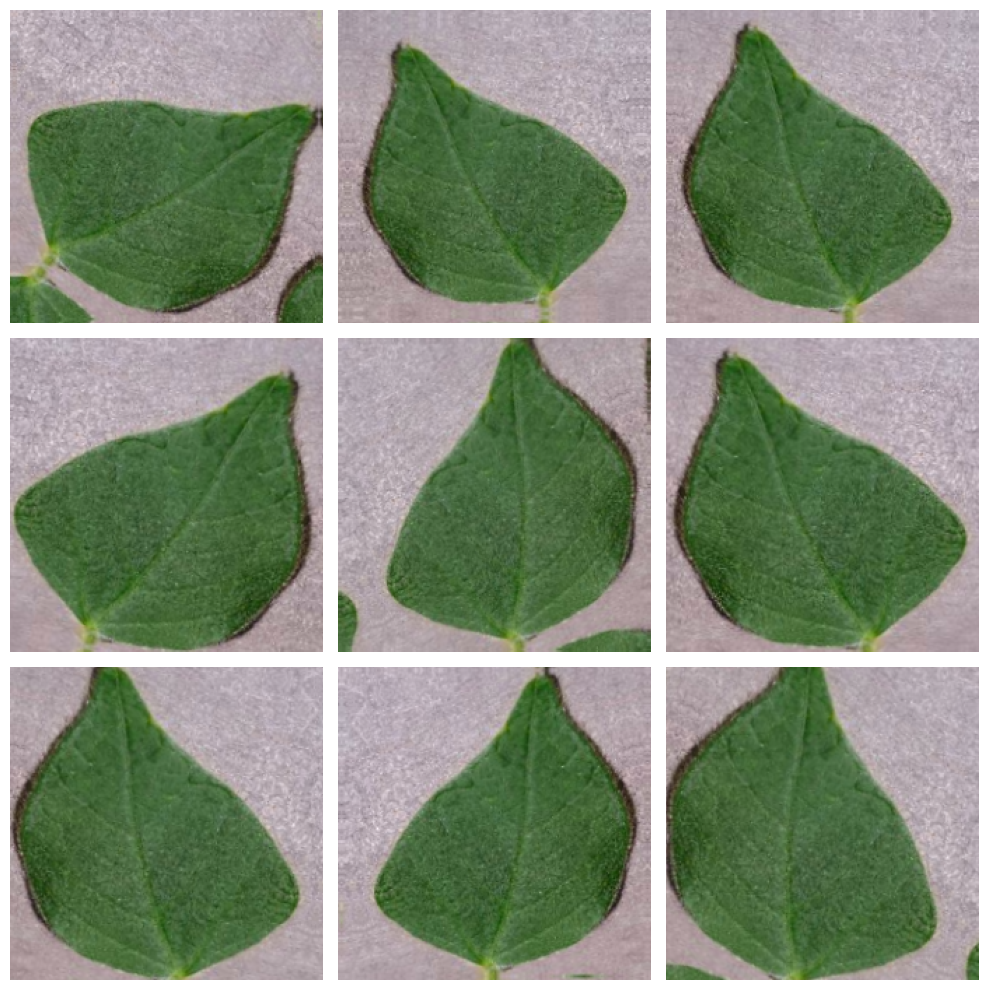

In [31]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    image = images[0]

    plt.figure(figsize=(10,10))

    for i in range(9):

        augmented_image = augmentation(tf.expand_dims(image, 0))

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_image[0])

        plt.axis("off")

plt.tight_layout()
plt.show()